<a href="https://colab.research.google.com/github/Fahadkhan2450/-sleep-disorder-diagnosis-through-optimized-machine-learning-approaches/blob/main/Sleep_Disorder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Path to dataset files: /kaggle/input/sleep-health-and-lifestyle-dataset


In [13]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

Analyzing Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(color_codes=True,style='darkgrid')

In [15]:
import pandas as pd

df = pd.read_csv('/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv')
#
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [16]:
df.shape

(374, 13)

### Observation


5 columns are object data type

Sum Null in sleep Disorder(target variables)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [18]:
df['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [19]:
df['Sleep Disorder']=df['Sleep Disorder'] = df['Sleep Disorder'].where(
    pd.notnull(df['Sleep Disorder']), 'No Disorder'
)

In [20]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [22]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


**Exploratory Data Analysis**

In [23]:
col_name= df.columns
col_name

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

**Unique Values**

In [24]:
df.nunique()

,0
Person ID,374
Gender,2
Age,31
Occupation,11
Sleep Duration,27
Quality of Sleep,6
Physical Activity Level,16
Stress Level,6
BMI Category,4
Blood Pressure,25


In [25]:
df.drop(columns='Person ID',inplace=True)

In [26]:
df.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder'],
      dtype='object')

**PAIR PLOT**

In [27]:
df[['Upper BP','Lower BP']]=df['Blood Pressure'].str.split('/',expand=True).astype(int)

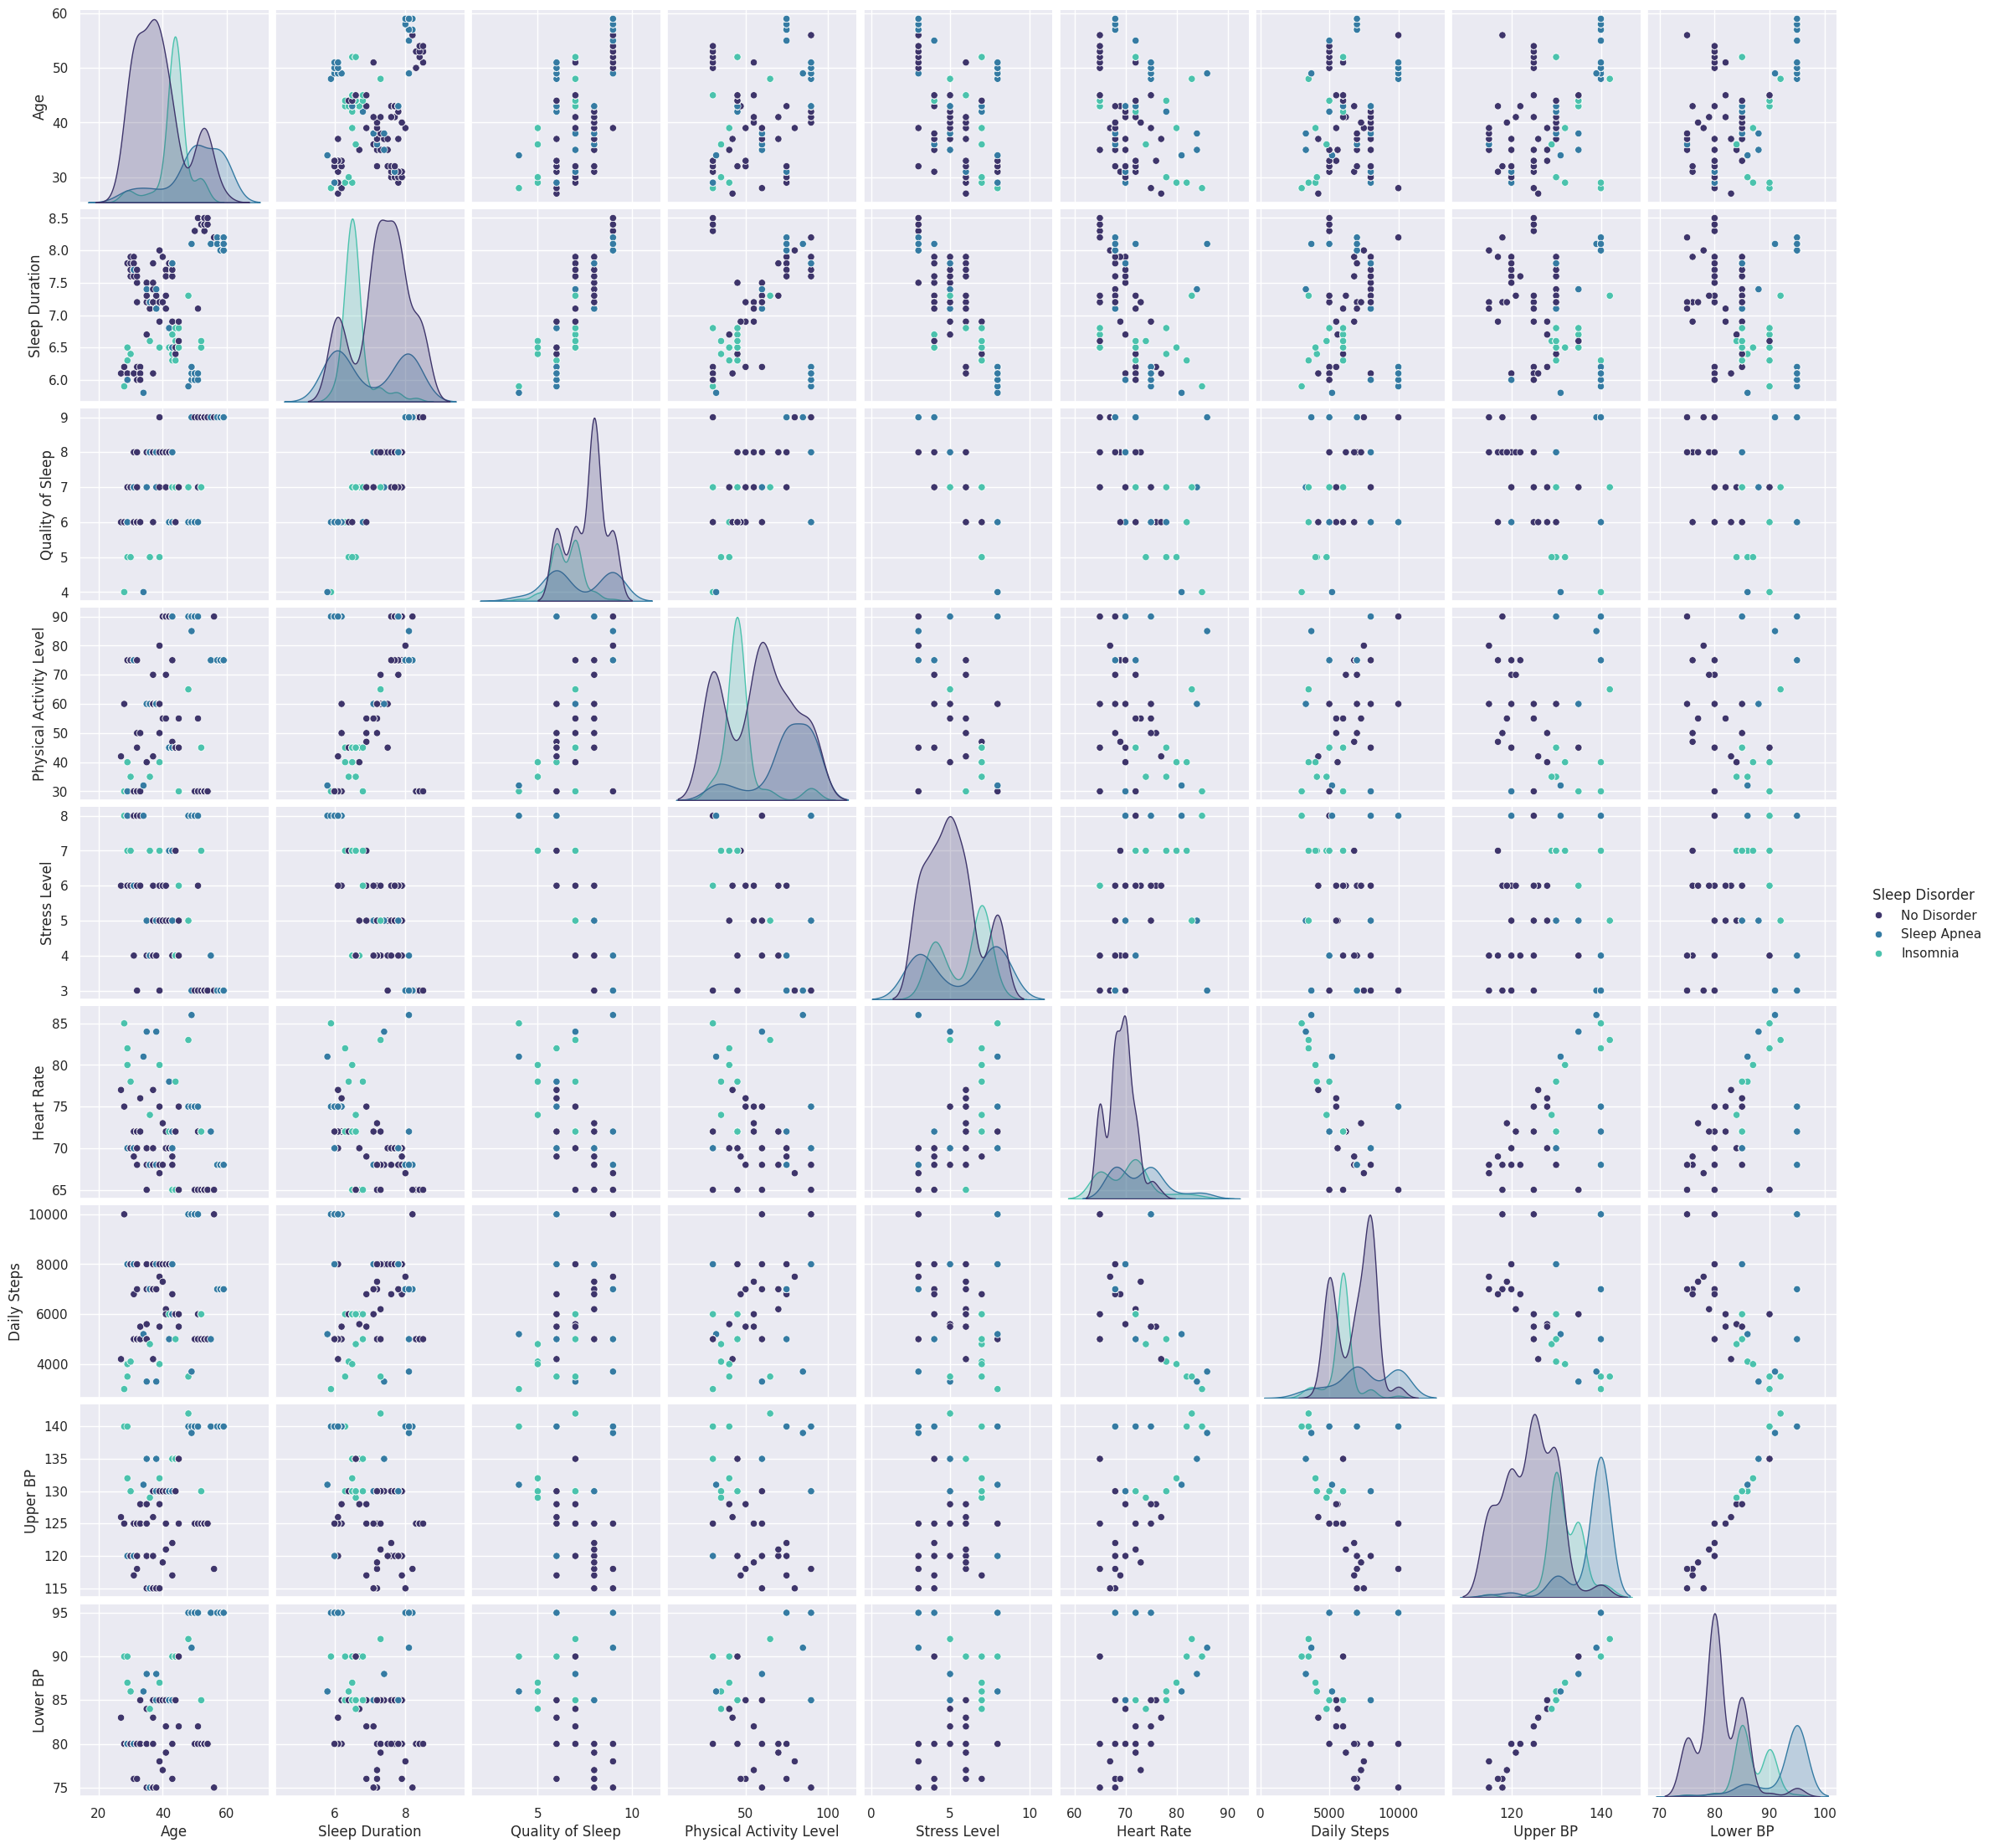

In [28]:
sns.pairplot(data=df,hue='Sleep Disorder',palette='mako')

In [29]:
df[['Upper BP','Lower BP']]

,Upper BP,Lower BP
0,126,83
1,125,80
2,125,80
3,140,90
4,140,90
...,...,...
369,140,95
370,140,95
371,140,95
372,140,95


**Histogram Distribution For Upper BP**

<Axes: xlabel='Upper BP', ylabel='Count'>

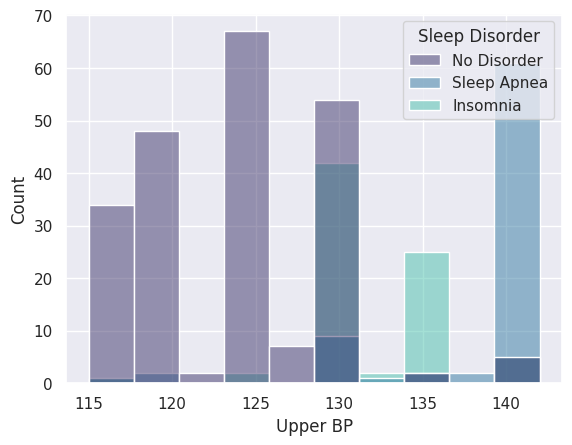

In [30]:
sns.histplot(data=df,x='Upper BP',hue='Sleep Disorder',palette='mako')

### **Histogram Distribution For Lower BP**

<Axes: xlabel='Lower BP', ylabel='Count'>

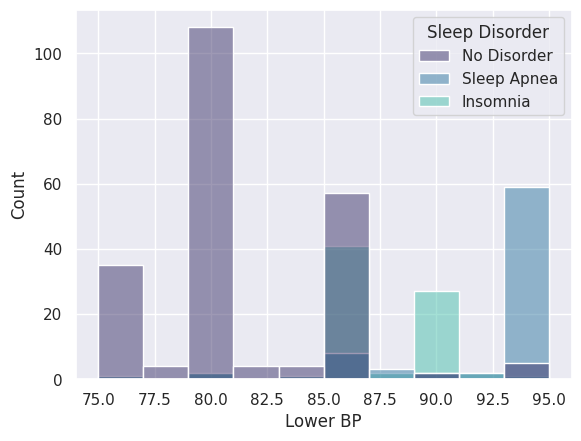

In [31]:
sns.histplot(data=df,x='Lower BP',hue='Sleep Disorder',palette='mako')

**Distribution of people based on sleep disorder**

In [32]:
fig=px.histogram(df,x='Sleep Disorder',color='Sleep Disorder',barmode='group')
fig.update(layout_title_text='Sleep Disorder')
fig.update_layout(title='Distribution of people based on sleep disorder')
fig.update_yaxes(showgrid=False)
fig.show()

Gender basis GroupBy

In [33]:
df['Gender'].groupby(df['Sleep Disorder']).value_counts()

Sleep Disorder  Gender
Insomnia        Male       41
                Female     36
No Disorder     Male      137
                Female     82
Sleep Apnea     Female     67
                Male       11
Name: count, dtype: int64

**Gender based sleep Disorder analyze**

<Axes: xlabel='Gender', ylabel='count'>

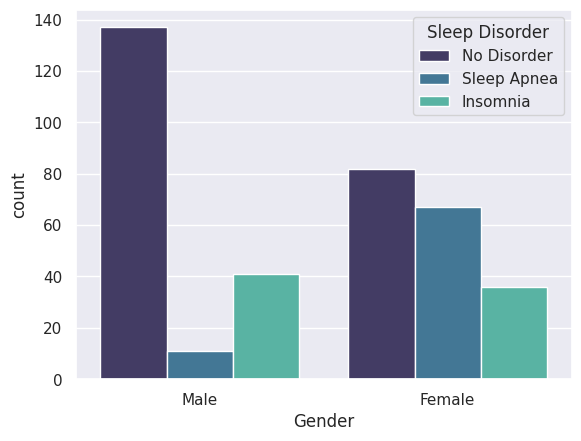

In [34]:
sns.countplot(data=df,x='Gender',hue='Sleep Disorder',palette='mako')

<Axes: ylabel='count'>

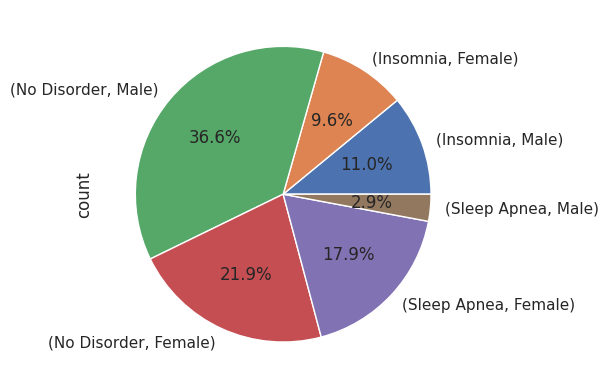

In [35]:
df['Gender'].groupby(df['Sleep Disorder']).value_counts().plot.pie(autopct='%1.1f%%')

In [36]:
df[['Upper BP','Lower BP']]=df['Blood Pressure'].str.split('/',expand=True).astype(int)
df.drop(columns='Blood Pressure',inplace=True)

In [37]:
df.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Sleep Disorder', 'Upper BP', 'Lower BP'],
      dtype='object')

**Plotting categorical Values**

In [38]:
cat_cols=df.select_dtypes(include='object').columns
num_cols=df.select_dtypes(exclude='object').columns


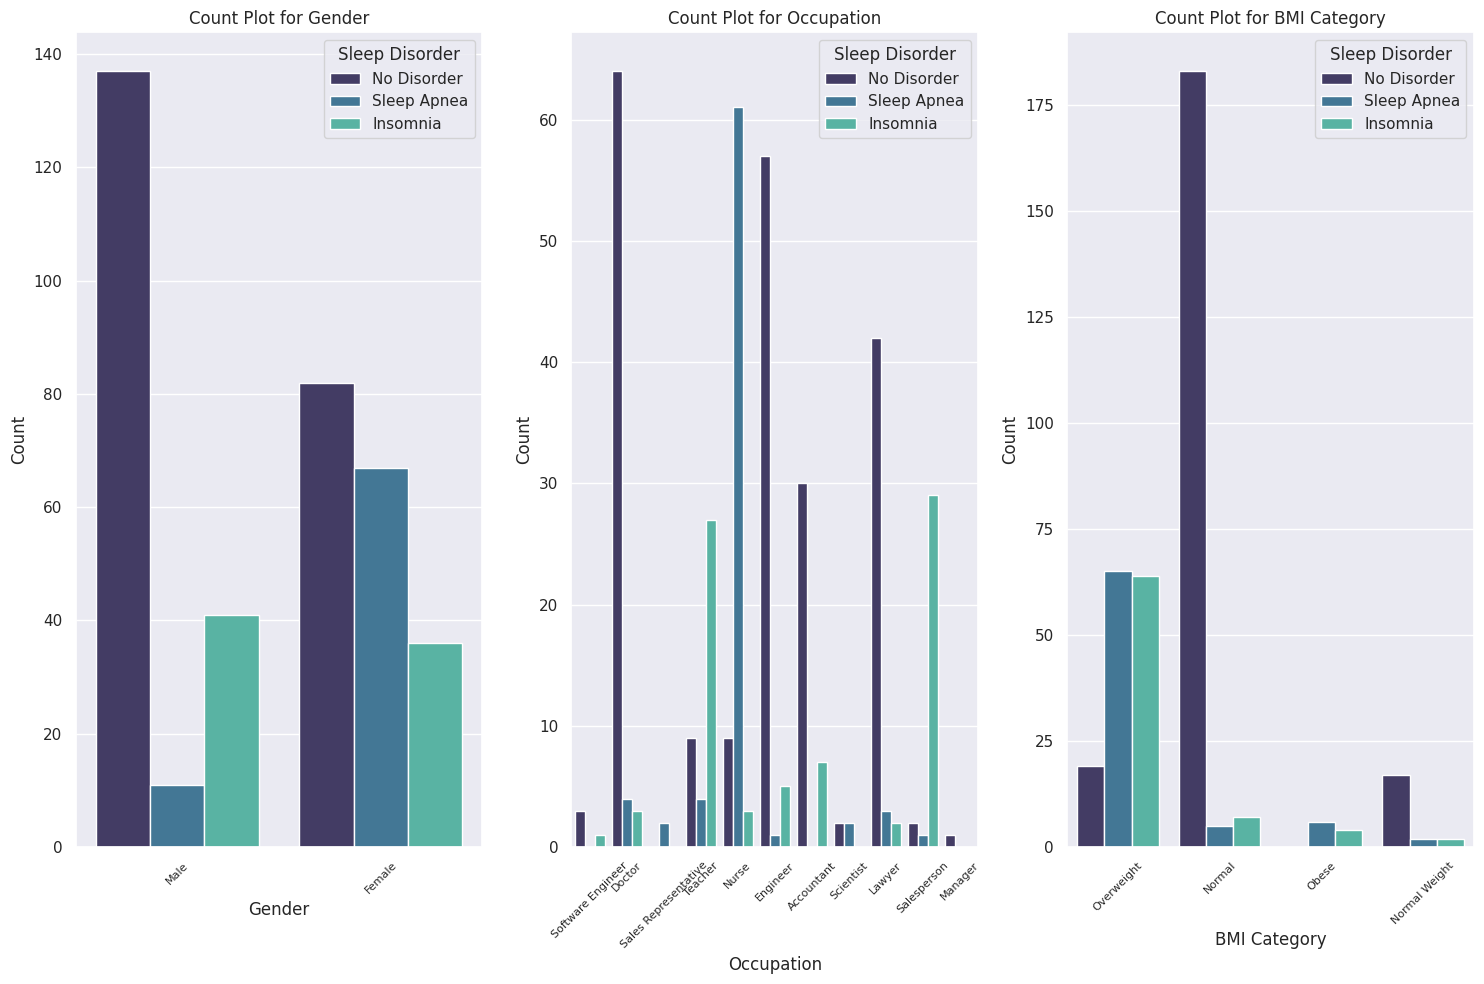

In [39]:
fig,axs=plt.subplots(1,3,figsize=(15,10))
axs=axs.flatten()

for i ,var in enumerate (cat_cols[:3]):
  sns.countplot(data=df,x=var,hue='Sleep Disorder',palette='mako',ax=axs[i])
  axs[i].set_title(f'Count Plot for {var}')
  axs[i].set_xlabel(var)
  axs[i].set_ylabel('Count')
  axs[i].legend(title='Sleep Disorder')
  axs[i].set_xticklabels(axs[i].get_xticklabels(),rotation=45)
  axs[i].tick_params(axis='x',labelsize=8)
plt.tight_layout()
plt.show()

In [40]:
# ##### Observation
# 1. Doctors have normal sleeps
# 2.Nurses are suffering from sleep Apnea
# 3.SalesPerson has highest Insomnia
# 4.Overweight people has higher chances of sleep disorder

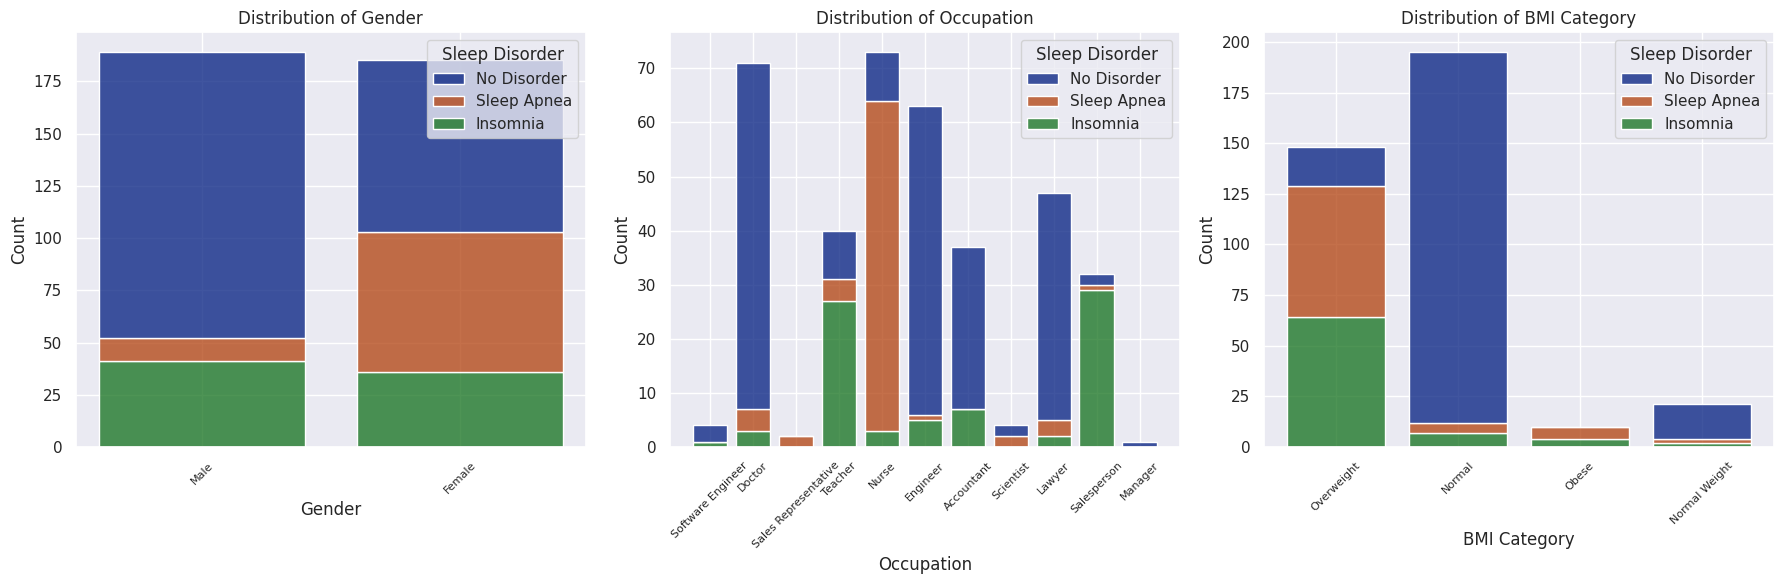

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs = axs.flatten()

for i, var in enumerate(cat_cols[:3]):
    sns.histplot(
        data=df,
        x=var,
        hue='Sleep Disorder',
        palette='dark',
        multiple='stack',   # or 'dodge'
        shrink=0.8,
        ax=axs[i]
    )

    axs[i].set_title(f'Distribution of {var}')
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Count')
    axs[i].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

**BoxPlot for Sleep Duration by ,Gender, Occupation ,Category**

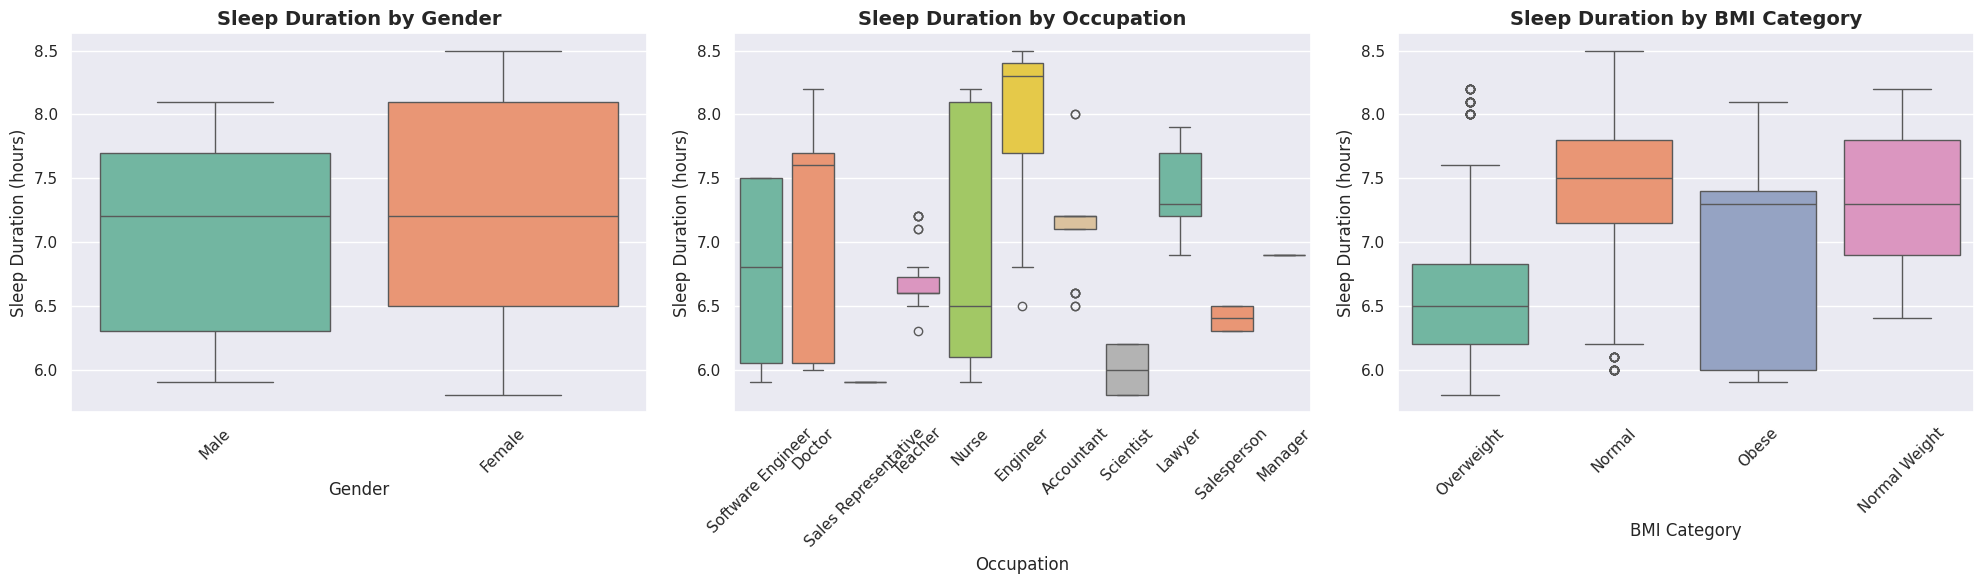

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
axs = axs.flatten()

for i, var in enumerate(cat_cols[:3]):
    sns.boxplot(
        data=df,
        x=var,
        y='Sleep Duration',
        palette='Set2',
        ax=axs[i]
    )

    axs[i].set_title(f'Sleep Duration by {var}', fontsize=14, fontweight='bold')
    axs[i].set_xlabel(var, fontsize=12)
    axs[i].set_ylabel('Sleep Duration (hours)', fontsize=12)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Sleep Disorder On the basis of Stress level**

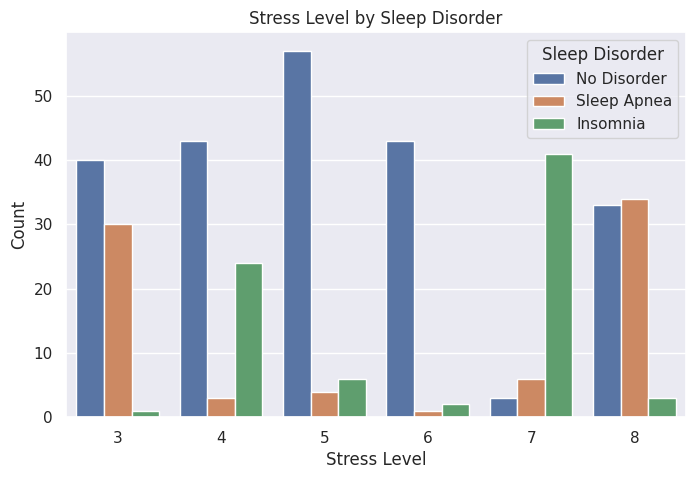

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Stress Level',
    hue='Sleep Disorder',
    palette='deep'
)

plt.title('Stress Level by Sleep Disorder')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.legend(title='Sleep Disorder')
plt.show()

**BMI Category Distribution by Sleep Disorder**

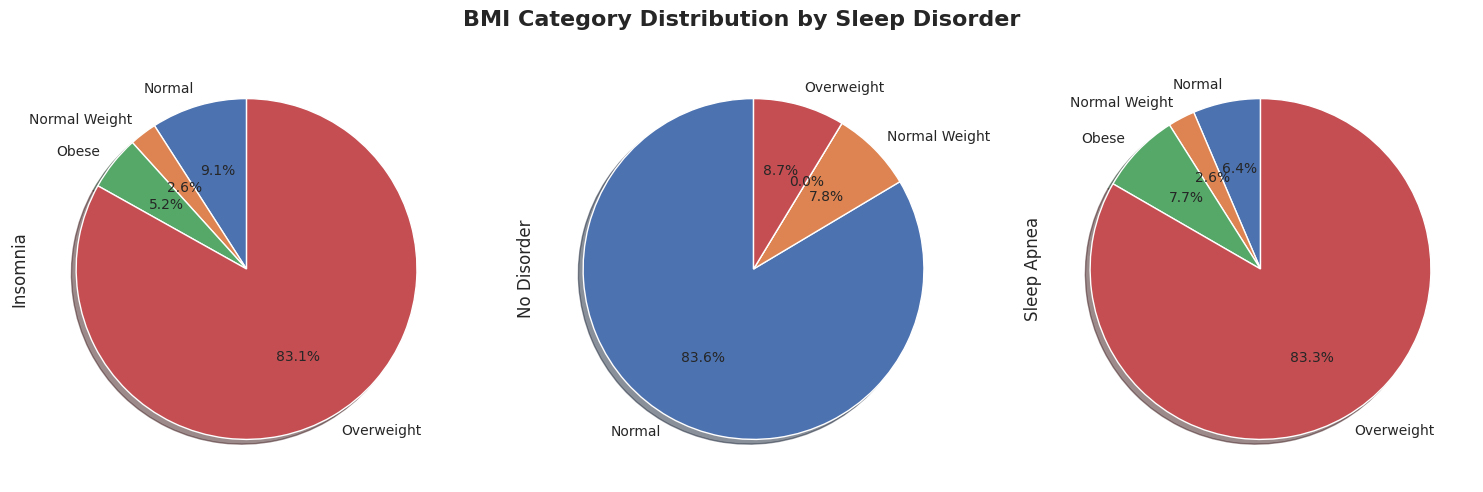

In [44]:
import matplotlib.pyplot as plt

pivot = df.pivot_table(
    index='BMI Category',
    columns='Sleep Disorder',
    aggfunc='size',
    fill_value=0
)

pivot.plot(
    kind='pie',
    subplots=True,
    figsize=(15, 5),
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    legend=False,
    textprops={'fontsize': 10}
)

plt.suptitle('BMI Category Distribution by Sleep Disorder',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**Data Preprocessing**

**Check Missing Values**

In [45]:
df.isnull().sum()

,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Heart Rate,0
Daily Steps,0


**label Encode categorial values**

In [46]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Occupation'] = label_encoder.fit_transform(df['Occupation'])
df['BMI Category'] = label_encoder.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = label_encoder.fit_transform(df['Sleep Disorder'])
print(df)

     Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0         1   27           9             6.1                 6   
1         1   28           1             6.2                 6   
2         1   28           1             6.2                 6   
3         1   28           6             5.9                 4   
4         1   28           6             5.9                 4   
..      ...  ...         ...             ...               ...   
369       0   59           5             8.1                 9   
370       0   59           5             8.0                 9   
371       0   59           5             8.1                 9   
372       0   59           5             8.1                 9   
373       0   59           5             8.1                 9   

     Physical Activity Level  Stress Level  BMI Category  Heart Rate  \
0                         42             6             3          77   
1                         60             8             0       

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    int64  
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    int64  
 11  Upper BP                 374 non-null    int64  
 12  Lower BP                 374 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 38.1 KB


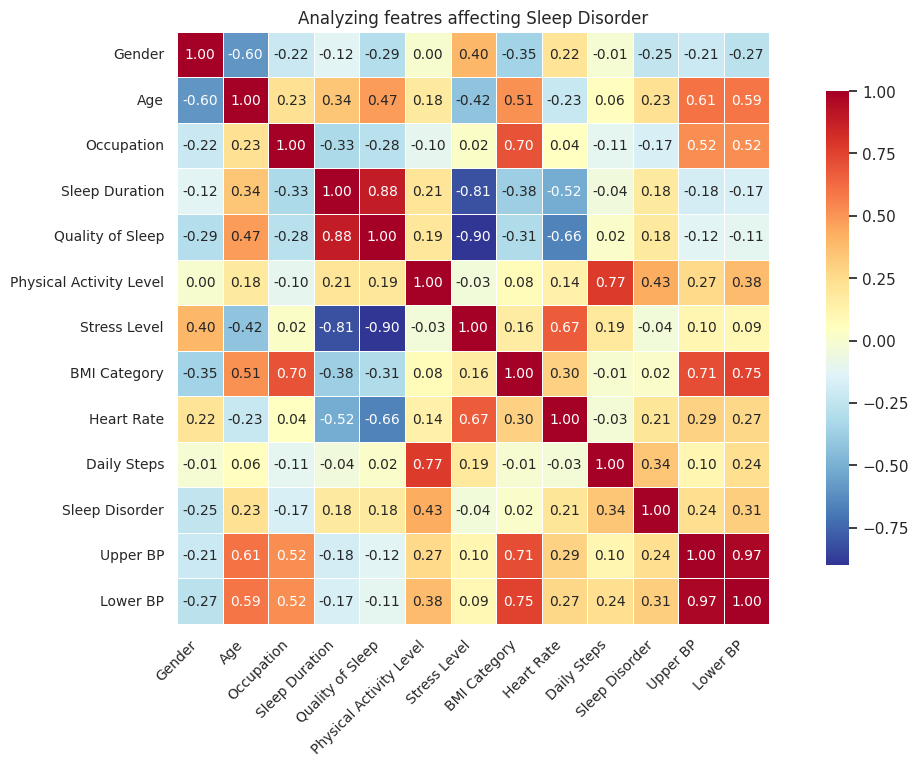

In [48]:
plt.figure(figsize=(12, 8))
cor=df.corr(numeric_only=True)
sns.heatmap(
    cor,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',      # Try: 'coolwarm', 'YlGnBu', 'viridis', 'crest'
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 10}
)

plt.title('Correlation Heatmap', fontsize=18, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.title('Analyzing featres affecting Sleep Disorder')
plt.show()

In [83]:
from sklearn.model_selection import train_test_split

X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train/Test using Logistic Regression**

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(
    C=5,
    max_iter=3000,
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train_scaled , y_train)

y_pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9466666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       1.00      0.98      0.99        44
           2       0.84      1.00      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75


Confusion Matrix:

[[12  0  3]
 [ 1 43  0]
 [ 0  0 16]]


In [85]:
lr.score(X_train_scaled,y_train)


0.8963210702341137

In [86]:
lr.score(X_test_scaled,y_test)

0.92

Train: 0.8963210702341137
Test : 0.92


In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9466666666666667
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.98      0.99        44
           2       1.00      0.81      0.90        16

    accuracy                           0.95        75
   macro avg       0.93      0.93      0.92        75
weighted avg       0.96      0.95      0.95        75



In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       1.00      1.00      1.00        44
           2       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75



In [92]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski'
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       1.00      0.95      0.98        44
           2       0.88      0.94      0.91        16

    accuracy                           0.93        75
   macro avg       0.90      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75



In [94]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9733333333333334
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       1.00      1.00      1.00        44
           2       0.89      1.00      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.98      0.97      0.97        75



In [95]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9733333333333334
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       1.00      1.00      1.00        44
           2       0.94      0.94      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



In [96]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9466666666666667
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       1.00      1.00      1.00        44
           2       0.93      0.81      0.87        16

    accuracy                           0.95        75
   macro avg       0.92      0.92      0.91        75
weighted avg       0.95      0.95      0.95        75



In [97]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize AdaBoost Classifier
ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.5,
    random_state=42
)

# Train the model
ada.fit(X_train, y_train)

# Make predictions
y_pred = ada.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9733333333333334
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       1.00      1.00      1.00        44
           2       0.89      1.00      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.98      0.97      0.97        75



In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": (lr, X_train_scaled, X_test_scaled),
    "Decision Tree": (dt, X_train, X_test),
    "Random Forest": (rf, X_train, X_test),
    "KNN": (knn, X_train_scaled, X_test_scaled),
    "SVM": (svm, X_train_scaled, X_test_scaled),
    "Naive Bayes": (nb, X_train, X_test),
    "Gradient Boosting": (gb, X_train, X_test),
    "AdaBoost": (ada, X_train, X_test),
    "XGBoost": (xgb, X_train, X_test)
}

for name, (model, Xtr, Xte) in models.items():

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, average="weighted"),
        "Recall": recall_score(y_test, test_pred, average="weighted"),
        "F1-Score": f1_score(y_test, test_pred, average="weighted")
    })

results = pd.DataFrame(results)

# Convert to percentage
results.iloc[:, 1:] = (results.iloc[:, 1:] * 100).round(2)

# Sort by Test Accuracy
results = results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

print(results)

                 Model  Train Accuracy  Test Accuracy  Precision  Recall  \
0                  SVM           91.30          97.33      97.63   97.33   
1             AdaBoost           90.64          97.33      97.63   97.33   
2    Gradient Boosting           92.31          97.33      97.33   97.33   
3        Random Forest           91.64          96.00      96.06   96.00   
4  Logistic Regression           90.64          94.67      95.09   94.67   
5              XGBoost           91.97          94.67      94.95   94.67   
6        Decision Tree           91.30          94.67      95.79   94.67   
7                  KNN           92.64          93.33      93.74   93.33   
8          Naive Bayes           86.96          93.33      94.13   93.33   

   F1-Score  
0     97.32  
1     97.32  
2     97.33  
3     95.99  
4     94.64  
5     94.66  
6     94.77  
7     93.47  
8     93.54  


**Perfoming hyperparameter tuning to improve the model**

In [99]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'saga'],
    'max_iter': [1000, 2000]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
0.8929378531073446


In [102]:
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,7,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train,y_train)

best_dt = grid_dt.best_estimator_
print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
0.8863276836158193


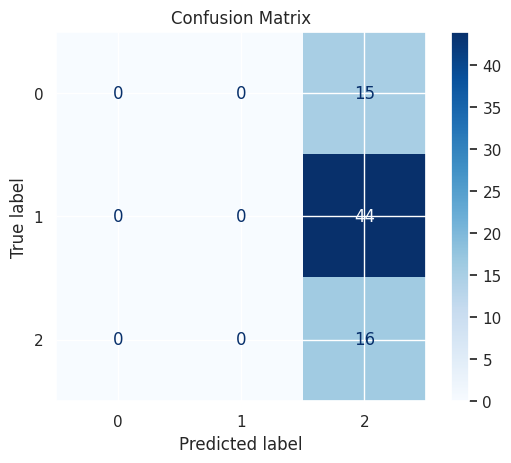

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = lr     # replace with your best model

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [105]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from sklearn.multiclass import OneVsRestClassifier

In [106]:
classes = sorted(y.unique())

y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_train_bin.shape[1]

In [107]:
models = {

    "SVM": OneVsRestClassifier(
        SVC(probability=True, random_state=42)
    ),

    "Gradient Boosting": OneVsRestClassifier(
        GradientBoostingClassifier(random_state=42)
    ),

    "AdaBoost": OneVsRestClassifier(
        AdaBoostClassifier(random_state=42)
    ),

    "XGBoost": OneVsRestClassifier(
        XGBClassifier(
            eval_metric="mlogloss",
            random_state=42
        )
    )

}

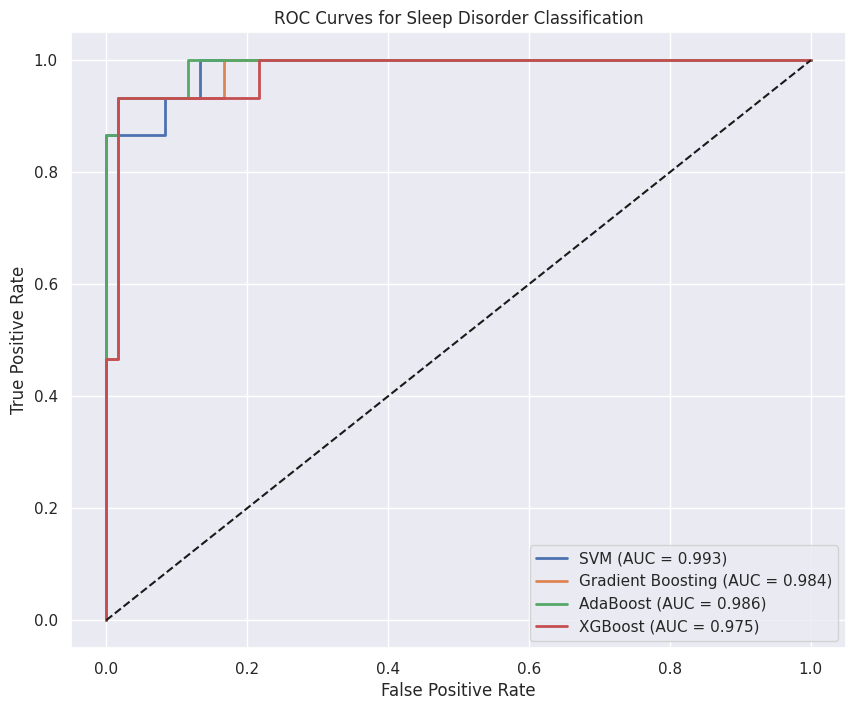

In [108]:
plt.figure(figsize=(10,8))

for name, model in models.items():

    if name == "SVM":
        model.fit(X_train_scaled, y_train_bin)
        y_score = model.predict_proba(X_test_scaled)

    else:
        model.fit(X_train, y_train_bin)
        y_score = model.predict_proba(X_test)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    macro_auc = sum(roc_auc.values()) / n_classes

    plt.plot(
        fpr[0],
        tpr[0],
        linewidth=2,
        label=f"{name} (AUC = {macro_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Sleep Disorder Classification")
plt.legend()

plt.grid(True)

plt.show()

In [111]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "Logistic Regression": (lr, X_train_scaled),
    "Decision Tree": (dt, X_train),
    "Random Forest": (rf, X_train),
    "KNN": (knn, X_train_scaled),
    "SVM": (svm, X_train_scaled),
    "Naive Bayes": (nb, X_train),
    "Gradient Boosting": (gb, X_train),
    "AdaBoost": (ada, X_train),
    "XGBoost": (xgb, X_train)
}

for name, (model, X_data) in models.items():

    scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy (%)": scores.mean()*100,
        "Std Dev (%)": scores.std()*100
    })

cv_results = pd.DataFrame(cv_results)

cv_results.iloc[:,1:] = cv_results.iloc[:,1:].round(2)

cv_results = cv_results.sort_values(
    by="Mean CV Accuracy (%)",
    ascending=False
)

print(cv_results)

                 Model  Mean CV Accuracy (%)  Std Dev (%)
8              XGBoost                 89.63         1.94
0  Logistic Regression                 89.30         2.70
4                  SVM                 89.29         2.92
2        Random Forest                 88.96         3.89
6    Gradient Boosting                 88.63         2.85
7             AdaBoost                 88.29         4.08
5          Naive Bayes                 87.61         3.50
1        Decision Tree                 86.95         3.56
3                  KNN                 85.62         3.42


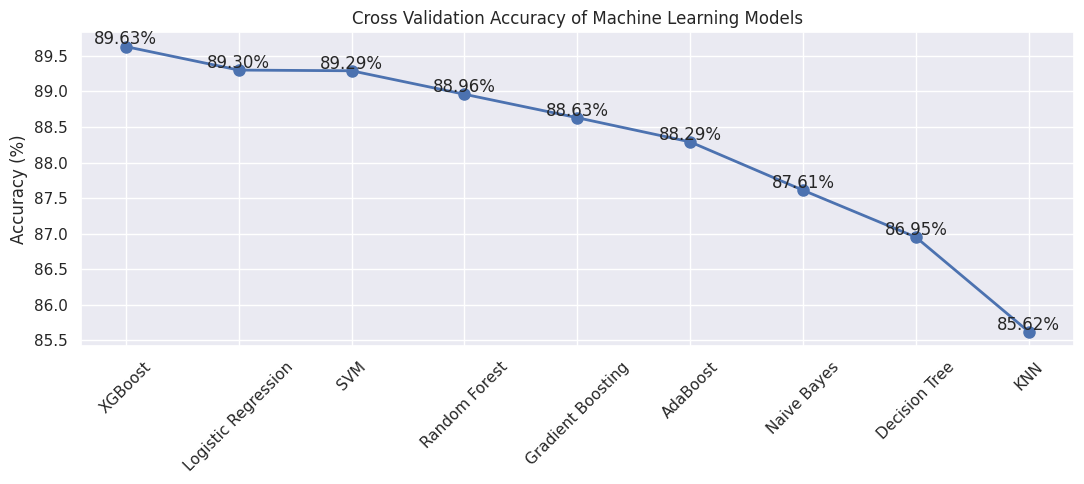

In [113]:
import matplotlib.pyplot as plt

cv_results = cv_results.sort_values(
    "Mean CV Accuracy (%)",
    ascending=False
)

plt.figure(figsize=(11,5))

plt.plot(
    cv_results["Model"],
    cv_results["Mean CV Accuracy (%)"],
    marker='o',
    linewidth=2,
    markersize=8
)

for x, y in zip(
    cv_results["Model"],
    cv_results["Mean CV Accuracy (%)"]
):
    plt.text(x, y+0.03, f"{y:.2f}%", ha='center')

plt.xticks(rotation=45)

plt.ylabel("Accuracy (%)")

plt.title("Cross Validation Accuracy of Machine Learning Models")

plt.grid(True)

plt.tight_layout()

plt.show()